In [1]:
#activate venv: 
import pandas as pd
import time
#other requirements: sklearn, matplotlib, statsmodels

In [2]:
start=time.perf_counter()

In [3]:
from DatabaseCreator import DatabaseCreator
import CJDH_local_settings
from FPLRunningAveragesCalculator import FPLRunningAveragesCalculator

current_season = 20252026
current_gw = 35 #predictions from gw+1

start=time.perf_counter()

if __name__ == "__main__":
    #Run Database Creator
    db_creator = DatabaseCreator(db_settings=CJDH_local_settings.local_settings['FPL_Points_Predictor'])
    fpl_engine = db_creator.get_engine_for("fpl_data_analysis")

    # Initialize the calculator
    calculator = FPLRunningAveragesCalculator(db_creator)
    
    # Define metrics to average
    metrics = ['minutes', 'total_points', 'team_elo', 'opp_team_elo',
        'goals_scored', 'assists', 'bonus', 'bps', 'clean_sheets', 'goals_conceded',
        'expected_goals', 'expected_assists', 'expected_goal_involvements',
        'expected_goals_conceded', 'cbi', 'defensive_contribution',
        'recoveries', 'tackles', 'saves'
    ]
    
    # Define interaction pairs
    interaction_pairs = [
        ('expected_goal_involvements', 'defensive_contribution'),
    ]
    
    # Calculate running averages
    df = calculator.calculate(
        metrics_to_average=metrics,
        window_sizes=[3, 5, 10],
        include_alltime=True,
        include_per_90=True,
        include_raw=True,
        include_elo_adjusted=True,
        include_squared_per_90=True,
        interaction_pairs=interaction_pairs
    )

    # Identify columns to exclude from forward filling (all fpl playergwdf columns) real life data columns
    exclude_cols = ['player_name_id', 'season', 'event',
                    'fixture', 'total_points', 'minutes',
                    'goals_scored', 'assists', 'team_elo', 'opp_team_elo',
                    'position', 'bonus', 'bps', 'clean_sheets',
                    'goals_conceded', 'was_home', 'expected_assists',
                    'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded',
                    'starts', 'team_name', 'opp_team_name',
                    'cbi','defensive_contribution','recoveries','tackles',
                    'saves']

    # Create a mask for rows to fill: season 20252026 and event > current_gw
    mask = (df['season'] == current_season) & (df['event'] > current_gw)

    # Get columns to fill
    cols_to_fill = [col for col in df.columns if col not in exclude_cols]

    # Sort by player and event to ensure proper order
    df = df.sort_values(['season', 'player_name_id', 'event'])

    # Forward fill only for the masked rows
    df_filled = df.copy()

    for col in cols_to_fill:
        # Forward fill within each player group
        df_filled.loc[mask, col] = df_filled.groupby('player_name_id')[col].ffill()[mask]

    table_name = "playergw_transformed"
    db_creator.create_staging_table_then_insert_data(table_name, data=df_filled)
    playergw_transformed = db_creator.table_to_df(table_name=table_name)
    
    finish=time.perf_counter()
    print("playergw_transformed inserted into psql")
    print(f'Finished in {round(((finish-start)/60),2)} minute(s)')
    print(playergw_transformed.info())

playergw_transformed inserted into psql
Finished in 24.2 minute(s)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155715 entries, 0 to 155714
Columns: 454 entries, player_name_id to saves_elo_p90sq_10
dtypes: float64(449), object(5)
memory usage: 539.4+ MB
None


In [4]:
from DatabaseCreator import DatabaseCreator
import CJDH_local_settings
from FPLPredictor import FPLPredictor

cbi_defcon_cols = [
    'cbi_at',
    'cbi_p90_at',
    'cbi_3',
    'cbi_p90_3',
    'cbi_elo_3',
    'cbi_elo_p90_3',
    'cbi_5',
    'cbi_p90_5',
    'cbi_elo_5',
    'cbi_elo_p90_5',
    'cbi_10',
    'cbi_p90_10',
    'cbi_elo_10',
    'cbi_elo_p90_10',
    'defensive_cont_at',
    'defensive_cont_p90_at',
    'defensive_cont_3',
    'defensive_cont_p90_3',
    'defensive_cont_elo_3',
    'defensive_cont_elo_p90_3',
    'defensive_cont_5',
    'defensive_cont_p90_5',
    'defensive_cont_elo_5',
    'defensive_cont_elo_p90_5',
    'defensive_cont_10',
    'defensive_cont_p90_10',
    'defensive_cont_elo_10',
    'defensive_cont_elo_p90_10',
    'saves_at',
    'saves_p90_at',
    'saves_3',
    'saves_p90_3',
    'saves_elo_3',
    'saves_elo_p90_3',
    'saves_5',
    'saves_p90_5',
    'saves_elo_5',
    'saves_elo_p90_5',
    'saves_10',
    'saves_p90_10',
    'saves_elo_10',
    'saves_elo_p90_10',
    'recoveries_at',
    'recoveries_p90_at',
    'recoveries_3',
    'recoveries_p90_3',
    'recoveries_elo_3',
    'recoveries_elo_p90_3',
    'recoveries_5',
    'recoveries_p90_5',
    'recoveries_elo_5',
    'recoveries_elo_p90_5',
    'recoveries_10',
    'recoveries_p90_10',
    'recoveries_elo_10',
    'recoveries_elo_p90_10',
    'tackles_at',
    'tackles_p90_at',
    'tackles_3',
    'tackles_p90_3',
    'tackles_elo_3',
    'tackles_elo_p90_3',
    'tackles_5',
    'tackles_p90_5',
    'tackles_elo_5',
    'tackles_elo_p90_5',
    'tackles_10',
    'tackles_p90_10',
    'tackles_elo_10',
    'tackles_elo_p90_10'
]

#Run Database Creator
if __name__ == "__main__":
    db_creator = DatabaseCreator(db_settings=CJDH_local_settings.local_settings['FPL_Points_Predictor'])
    fpl_engine = db_creator.get_engine_for("fpl_data_analysis")

    # Load df from sql
    df = db_creator.run_sql("""SELECT *
                            FROM playergw_transformed
                            """)
    print("=" * 80)
    print("Checking NaN Summary")
    print("=" * 80)

    temp_filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)
    temp_predictor = FPLPredictor(
        data=df[temp_filtered],
        target='expected_goals_per90',
        positions={'FWD', 'MID','DEF'},
        columns_to_drop=cbi_defcon_cols
    )
    nan_summary = temp_predictor.get_nan_summary()

Checking NaN Summary

NaN Summary for 310 potential features:
Total rows: 43734

Features with NaN values:
                                       feature  nan_count  nan_pct  non_null_count
                           tackles_elo_p90sq_3      37368    85.44            6366
                               tackles_p90sq_3      37368    85.44            6366
                               cbi_elo_p90sq_3      37368    85.44            6366
                                   cbi_p90sq_3      37368    85.44            6366
                            recoveries_p90sq_3      37368    85.44            6366
                        recoveries_elo_p90sq_3      37368    85.44            6366
                        defensive_cont_p90sq_3      37368    85.44            6366
                    defensive_cont_elo_p90sq_3      37368    85.44            6366
                        recoveries_elo_p90sq_5      37305    85.30            6429
                            recoveries_p90sq_5      37305    85

In [5]:
# #restricts to player_name_id who have >0 minutes in that season
# #model struggles to predict higher values, so maybe cut-off points at 10, or try log(points) as a depvar
# for each indepvar: filter outliers & standardize

In [6]:
# #Optimizing hyperparameters

# filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['expected_goals']>0)

# if __name__ == "__main__":

#     print("\n" + "=" * 80)
#     print("FWD xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)
    
#     FWD_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'FWD'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300]
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     FWD_xG_predictor.fit()
#     FWD_xG_predictor.plot_cv_results()
    
#     # Get best parameters in grid format
#     FWD_params_grid = FWD_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     FWD_xG_errors = FWD_xG_predictor.get_largest_errors(return_full_data=True)

#     print("\n" + "=" * 80)
#     print("MID xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)

#     MID_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'MID'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300] # cannot be larger than sample size!
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     MID_xG_predictor.fit()
#     MID_xG_predictor.plot_cv_results()

#     # Get best parameters in grid format
#     MID_params_grid = MID_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     MID_xG_errors = MID_xG_predictor.get_largest_errors(return_full_data=True)

#     print("\n" + "=" * 80)
#     print("DEF xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)

#     DEF_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'DEF'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300]
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     DEF_xG_predictor.fit()
#     DEF_xG_predictor.plot_cv_results()

#     # Get best parameters in grid format
#     DEF_params_grid = DEF_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     DEF_xG_errors = DEF_xG_predictor.get_largest_errors(return_full_data=True)


In [7]:
# print(FWD_params_grid)
# print(MID_params_grid)
# print(DEF_params_grid)

In [8]:
FWD_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}
MID_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}
DEF_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}

In [9]:
# target=expected_goals_per90, FWD_xG_predictor
# Cleaned df size: 2450/4170

# Performing GridSearchCV hyperparameter optimization...
# Parameter grid: {'n_estimators': [200], 'max_depth': [20, 30, 50], 'min_samples_split': [500]}
# Cross-validation folds: 5
# Fitting 5 folds for each of 3 candidates, totalling 15 fits

# Best parameters found:
#   max_depth: 20
#   min_samples_split: 500
#   n_estimators: 200

# Best CV RMSE: 0.4231

# Training Set Performance:
# R² Score: 0.1823
# RMSE: 0.4056
# MAE: 0.2978

# Test Set Performance:
# R² Score: 0.1273
# RMSE: 0.4301
# MAE: 0.3197

In [10]:
mins_filter = (df['player_season_minutes_total']>100)&(df['minutes']>0)

if __name__ == "__main__":
    
    FWD_mins_predictor = FPLPredictor(
                data=df[mins_filter],
        target='minutes',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=50
        )
    FWD_mins_predictor.fit()
    # FWD_mins_predictor.plot_results()

    MID_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=50
        )
    MID_mins_predictor.fit()
    # MID_mins_predictor.plot_results()

    DEF_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=50
        )
    DEF_mins_predictor.fit()
    # DEF_mins_predictor.plot_results()

    GK_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10
        )
    GK_mins_predictor.fit()
    # GK_mins_predictor.plot_results()

Cleaned df size: 2789/8133

Training Set Performance:
R² Score: 0.8181
RMSE: 13.9436
MAE: 11.4554

Test Set Performance:
R² Score: 0.3919
RMSE: 25.6723
MAE: 20.8456

Top 20 Feature Importances:
                 feature  importance
               minutes_3    0.276554
           minutes_elo_3    0.080224
        team_elo_p90sq_5    0.015202
    opp_team_elo_p90sq_3    0.012702
       team_elo_p90sq_10    0.010732
   clean_sheets_p90sq_at    0.010670
   opp_team_elo_p90sq_at    0.010205
    opp_team_elo_p90sq_5    0.009767
               minutes_5    0.009034
opp_team_elo_elo_p90sq_5    0.008601
            opp_team_elo    0.008441
                team_elo    0.007835
       team_elo_p90sq_at    0.007513
          opp_team_elo_5    0.007483
   opp_team_elo_p90sq_10    0.007364
         xg_over_g_ratio    0.006712
                elo_diff    0.006669
            bps_p90sq_at    0.006572
        team_elo_p90sq_3    0.006336
                 assists    0.006185
Cleaned df size: 9583/30225



In [11]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)&(df['total_points']<12)

if __name__ == "__main__":
    
    print("target=expected_goals_per90, FWD_xG_predictor")
    FWD_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xG_predictor.fit()
    # FWD_xG_predictor.plot_results()

    print("target=expected_goals_per90, MID_xG_predictor")
    MID_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xG_predictor.fit()
    # MID_xG_predictor.plot_results()
    
    print("target=expected_goals_per90, DEF_xG_predictor")
    DEF_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xG_predictor.fit()
    # DEF_xG_predictor.plot_results()

target=expected_goals_per90, FWD_xG_predictor


Cleaned df size: 2841/4677

Training Set Performance:
R² Score: 0.5955
RMSE: 0.2497
MAE: 0.1999

Test Set Performance:
R² Score: -0.0030
RMSE: 0.3675
MAE: 0.2841

Top 20 Feature Importances:
                  feature  importance
                 elo_diff    0.049266
    goals_scored_p90sq_at    0.049024
          xg_over_g_ratio    0.028644
             opp_team_elo    0.020838
          opp_team_elo_10    0.016906
         team_elo_p90sq_3    0.016559
           bonus_p90sq_at    0.016471
           opp_team_elo_3    0.015598
     opp_team_elo_p90sq_3    0.013764
           opp_team_elo_5    0.012654
            minutes_elo_3    0.011571
    opp_team_elo_p90sq_at    0.011083
     opp_team_elo_p90sq_5    0.011013
           minutes_elo_10    0.010297
             bps_p90sq_at    0.010145
        team_elo_p90sq_at    0.009901
                    bps_3    0.009888
               team_elo_5    0.009817
total_points_elo_p90sq_10    0.009485
  goals_conceded_p90sq_at    0.009053
target=expe

In [12]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_assists_per90, FWD_xA_predictor")
    FWD_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xA_predictor.fit()
    # FWD_xA_predictor.plot_results()

    print("target=expected_assists_per90, MID_xA_predictor")
    MID_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xA_predictor.fit()
    # MID_xA_predictor.plot_results()
    
    print("target=expected_assists_per90, DEF_xA_predictor")
    DEF_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xA_predictor.fit()
    # DEF_xA_predictor.plot_results()

target=expected_assists_per90, FWD_xA_predictor
Cleaned df size: 3049/4982

Training Set Performance:
R² Score: 0.6187
RMSE: 0.0745
MAE: 0.0499

Test Set Performance:
R² Score: 0.0359
RMSE: 0.1119
MAE: 0.0693

Top 20 Feature Importances:
                feature  importance
                assists    0.119611
         opp_team_elo_3    0.036147
         assists_elo_10    0.033076
   goals_conceded_elo_3    0.019834
           opp_team_elo    0.013970
               elo_diff    0.013864
         opp_team_elo_5    0.013667
   total_points_p90sq_3    0.012776
 opp_team_elo_elo_p90_5    0.012590
         minutes_elo_10    0.010425
      team_elo_p90sq_at    0.009430
        opp_team_elo_10    0.009377
goals_conceded_p90sq_at    0.009232
     assists_elo_p90_10    0.009017
              bps_p90_5    0.008913
            bps_p90sq_5    0.008551
            bonus_elo_5    0.008543
        xg_over_g_ratio    0.008412
   assists_elo_p90sq_10    0.008363
      minutes_elo_p90_5    0.008303
target

In [13]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_goals_conceded_per90, FWD_xGC_predictor")
    FWD_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xGC_predictor.fit()
    # FWD_xGC_predictor.plot_results()

    print("target=expected_goals_conceded_per90, MID_xGC_predictor")
    MID_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xGC_predictor.fit()
    # MID_xGC_predictor.plot_results()
    
    print("target=expected_goals_conceded_per90, DEF_xGC_predictor")
    DEF_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xGC_predictor.fit()
    # DEF_xGC_predictor.plot_results()

    print("target=expected_goals_conceded_per90, GK_xGC_predictor")
    GK_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10)
    GK_xGC_predictor.fit()
    # GK_xGC_predictor.plot_results()

target=expected_goals_conceded_per90, FWD_xGC_predictor
Cleaned df size: 3049/4982

Training Set Performance:
R² Score: 0.6633
RMSE: 0.5327
MAE: 0.4335

Test Set Performance:
R² Score: 0.1450
RMSE: 0.8516
MAE: 0.6531

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.164706
           opp_team_elo    0.040086
        xg_over_g_ratio    0.031548
        opp_team_elo_10    0.018799
         opp_team_elo_5    0.015982
goals_conceded_p90sq_at    0.014998
         assists_p90_at    0.012935
     minutes_elo_p90_10    0.011620
         opp_team_elo_3    0.011296
       assists_p90sq_at    0.010447
  total_points_p90sq_at    0.010081
      team_elo_p90sq_at    0.009426
         bonus_p90sq_at    0.008934
  clean_sheets_p90sq_at    0.008928
  opp_team_elo_p90sq_at    0.007840
             assists_at    0.007712
             minutes_10    0.007357
   minutes_elo_p90sq_10    0.007331
            team_elo_10    0.007326
               team_elo    0.00727

In [14]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=bps_per90, FWD_bps_predictor")
    FWD_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90', # try: 'bonus_per90'
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_bps_predictor.fit()
    # FWD_bps_predictor.plot_results()

    print("target=bps_per90, MID_bps_predictor")
    MID_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_bps_predictor.fit()
    # MID_bps_predictor.plot_results()
    
    print("target=bps_per90, DEF_bps_predictor")
    DEF_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_bps_predictor.fit()
    # DEF_bps_predictor.plot_results()

    print("target=bps_per90, GK_bps_predictor")
    GK_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10)
    GK_bps_predictor.fit()
    # GK_bps_predictor.plot_results()

target=bps_per90, FWD_bps_predictor
Cleaned df size: 4461/4982

Training Set Performance:
R² Score: 0.5276
RMSE: 12.7282
MAE: 10.1624

Test Set Performance:
R² Score: 0.0477
RMSE: 17.7456
MAE: 13.6508

Top 20 Feature Importances:
                  feature  importance
                  assists    0.175878
                 elo_diff    0.039654
             opp_team_elo    0.021627
          opp_team_elo_10    0.019759
     minutes_elo_p90sq_10    0.017015
  goals_conceded_p90sq_at    0.014128
           opp_team_elo_3    0.013332
           bonus_p90sq_at    0.012598
           opp_team_elo_5    0.011994
      minutes_elo_p90sq_3    0.010439
clean_sheets_elo_p90sq_10    0.009937
             bps_p90sq_at    0.009884
     goals_conceded_elo_3    0.009497
                bps_elo_3    0.009494
         assists_p90sq_at    0.009167
    goals_scored_p90sq_at    0.008030
    opp_team_elo_p90sq_10    0.007383
  goals_scored_elo_p90_10    0.007345
             bonus_elo_10    0.007317
          

In [15]:
#shots saved
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=saves_per90, GK_saves_predictor")
    GK_saves_predictor = FPLPredictor(
        data=df[filtered],
        target='saves_per90',
        positions={'GK'},
        max_nan_pct=10)
    GK_saves_predictor.fit()
    # GK_saves_predictor.plot_results()

target=saves_per90, GK_saves_predictor


Cleaned df size: 4175/4450

Training Set Performance:
R² Score: 0.5647
RMSE: 1.2958
MAE: 1.0469

Test Set Performance:
R² Score: 0.0613
RMSE: 1.8279
MAE: 1.4208

Top 20 Feature Importances:
                    feature  importance
                   elo_diff    0.137554
               opp_team_elo    0.022983
             saves_p90sq_at    0.019503
            opp_team_elo_10    0.017913
             saves_p90sq_10    0.017612
             opp_team_elo_5    0.016431
      opp_team_elo_p90sq_at    0.015591
    goals_conceded_p90sq_at    0.014613
         saves_elo_p90sq_10    0.013942
             opp_team_elo_3    0.013100
          team_elo_p90sq_at    0.013073
              saves_p90sq_5    0.012239
   total_points_elo_p90sq_3    0.011755
      clean_sheets_p90sq_at    0.011628
          saves_elo_p90sq_5    0.011170
               bps_p90sq_at    0.010993
               bps_p90sq_10    0.010854
       opp_team_elo_p90sq_5    0.010580
goals_conceded_elo_p90sq_10    0.010380
      opp_

In [16]:
# >10 defcon (CBIT) for a defender
# >12 defcon (CBIT+R) for mid or fwd
filtered = (df['minutes']>30)&(df['player_season_minutes_total']>0)

if __name__ == "__main__":
    
    print("target=defensive_contribution_per90, FWD_defcon_predictor")
    FWD_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'FWD'},
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_defcon_predictor.fit()
    # FWD_defcon_predictor.plot_results()

    print("target=defensive_contribution_per90, MID_defcon_predictor")
    MID_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'MID'},
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_defcon_predictor.fit()
    # MID_defcon_predictor.plot_results()

    print("target=defensive_contribution_per90, DEF_defcon_predictor")
    DEF_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'DEF'},
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_defcon_predictor.fit()
    # DEF_defcon_predictor.plot_results()

target=defensive_contribution_per90, FWD_defcon_predictor
Cleaned df size: 774/5501

Training Set Performance:
R² Score: 0.7498
RMSE: 1.4721
MAE: 1.1782

Test Set Performance:
R² Score: 0.0761
RMSE: 2.7016
MAE: 2.0662

Top 20 Feature Importances:
                  feature  importance
               minutes_10    0.036836
          xg_over_g_ratio    0.035952
          opp_team_elo_10    0.022829
  goals_conceded_p90sq_at    0.022397
    clean_sheets_p90sq_at    0.019859
         team_elo_p90sq_5    0.018363
           assists_p90_at    0.017520
             opp_team_elo    0.015615
           opp_team_elo_5    0.014661
                 team_elo    0.014526
           opp_team_elo_3    0.013945
        team_elo_p90sq_at    0.013813
     total_points_p90sq_3    0.013509
    goals_scored_p90sq_at    0.012710
     opp_team_elo_p90sq_5    0.012562
                   bps_10    0.012259
                 elo_diff    0.011965
opp_team_elo_elo_p90sq_10    0.010882
       team_elo_elo_p90_5    0.

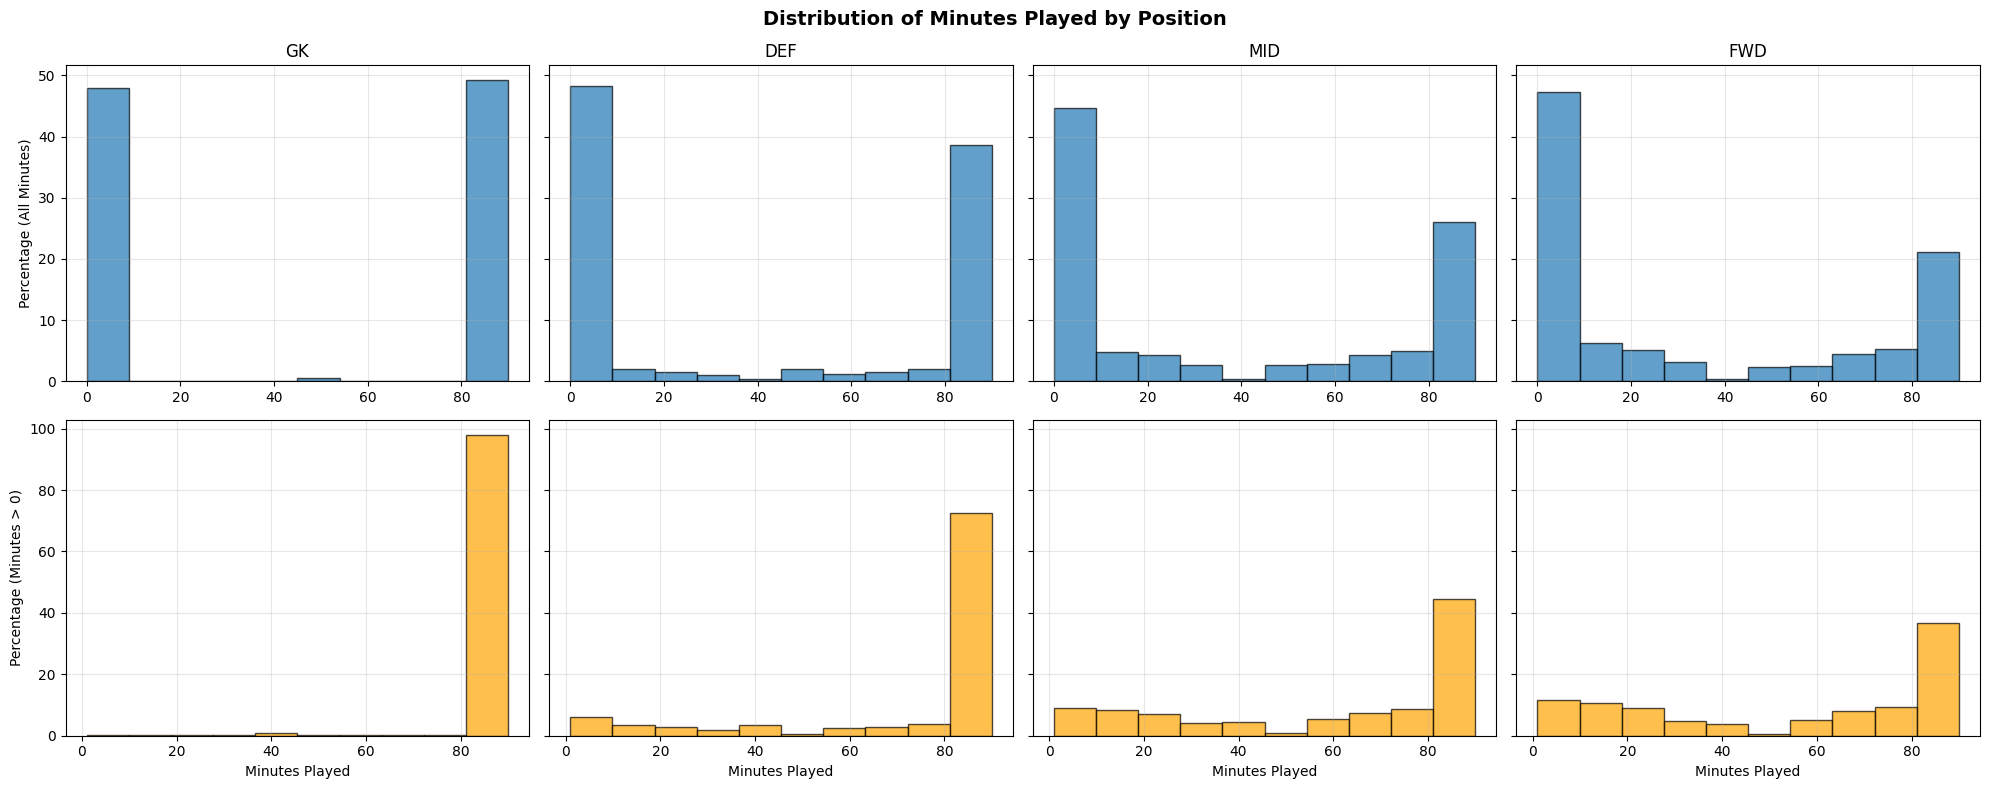

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Filter for specific positions
positions = ['GK', 'DEF', 'MID', 'FWD']
n_positions = len(positions)

# Create subplots with 2 rows
fig, axes = plt.subplots(2, n_positions, figsize=(5*n_positions, 8), sharey='row')

# Row 1: All data
for i, position in enumerate(positions):
    position_minutes = df[df['position'] == position]['minutes']
    axes[0, i].hist(position_minutes, bins=10, edgecolor='black', alpha=0.7, 
                    weights=100*np.ones(len(position_minutes))/len(position_minutes))
    axes[0, i].set_title(position)
    axes[0, i].grid(True, alpha=0.3)

axes[0, 0].set_ylabel('Percentage (All Minutes)')

# Row 2: Minutes > 0
for i, position in enumerate(positions):
    position_minutes = df[(df['position'] == position) & (df['minutes'] > 0)]['minutes']
    axes[1, i].hist(position_minutes, bins=10, edgecolor='black', alpha=0.7, color='orange',
                    weights=100*np.ones(len(position_minutes))/len(position_minutes))
    axes[1, i].set_xlabel('Minutes Played')
    axes[1, i].grid(True, alpha=0.3)

axes[1, 0].set_ylabel('Percentage (Minutes > 0)')

plt.suptitle('Distribution of Minutes Played by Position', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Goals conceded per 90
Estimated λ (mean goals per match): 1.366


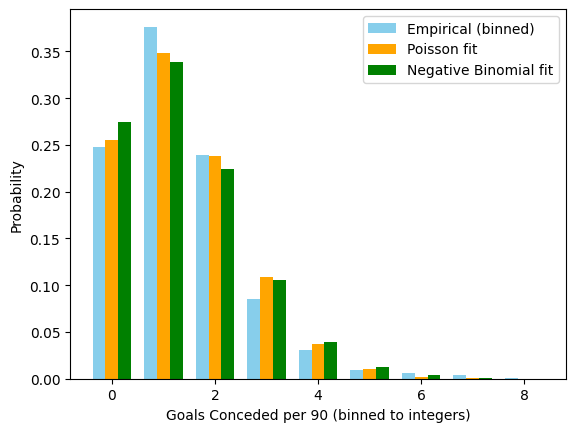

Mean: 1.356, Variance: 1.492
Overdispersion ratio (Var/Mean): 1.100
✅ Poisson assumption looks reasonable.
P(X < 1 goal) = 0.255


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("Goals conceded per 90")

# Compute xGC per 90
data = df.copy()
data['xgc_p90'] = (data['expected_goals_conceded'] / data['minutes']) * 90

# Filter to reasonable samples
data = data[(data['minutes'] > 0) & (data['xgc_p90'] < 8)]['xgc_p90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean goals per match): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('Goals Conceded per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")

# --- Example probability ---
p_less_than_1 = poisson.cdf(0, mu=lambda_hat)
print(f"P(X < 1 goal) = {p_less_than_1:.3f}")


Mids & Forwards
Estimated λ (mean defcon per 90): 8.191


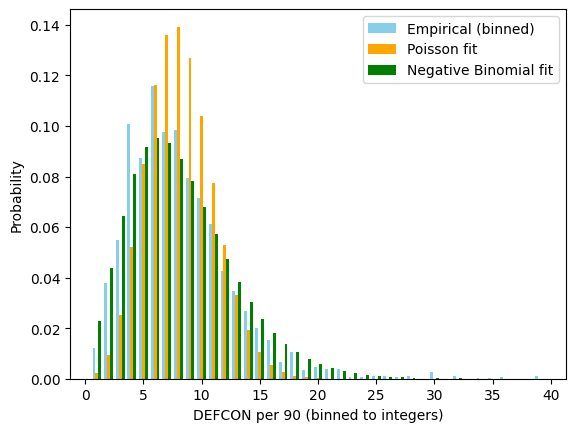

Mean: 8.184, Variance: 20.899
Overdispersion ratio (Var/Mean): 2.554
⚠️ Likely overdispersed → Negative Binomial may fit better.


In [19]:
#Test if defcon_p90 is neg binom distributed

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("Mids & Forwards")

# Filter to reasonable samples
data = df[(df['minutes'] > 0)
          & (df['defensive_contribution_per90'] > 0) 
          & (df['defensive_contribution_per90'] < 40)
          & (df['position'].isin(['DEF']))]['defensive_contribution_per90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean defcon per 90): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('DEFCON per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")


GK saves per 90
Estimated λ (mean saves per 90): 3.195


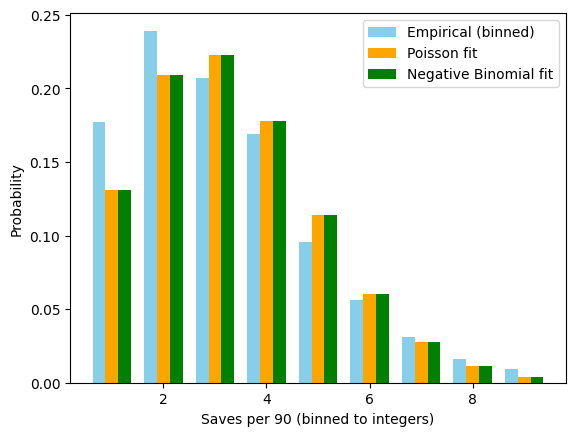

Mean: 3.195, Variance: 3.196
Overdispersion ratio (Var/Mean): 1.000
✅ Poisson assumption looks reasonable.


In [20]:
#Test if saves_p90 is neg binom distributed

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("GK saves per 90")

# Filter to reasonable samples
data = df[#(df['minutes'] > 0)
          (df['saves_per90'] > 0) 
          & (df['saves_per90'] < 10)
          & (df['position'].isin(['GK']))]['saves_per90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean saves per 90): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('Saves per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")


In [21]:
#Create the data which the prediction data should be added to
prediction_data = df[(df['season']==20252026)
                     &(df['event']>=current_gw+1)]

In [22]:
def predict_target_vectorized(df, model_dict, col_name):
    preds = []
    
    for pos, model in model_dict.items():
        subset = df[df['position'] == pos]
        if not subset.empty:
            pos_preds = model.predict_new(subset)
            temp = subset.copy()
            temp[col_name] = pos_preds
            preds.append(temp)
    
    if not preds:
        # If no positions matched at all
        return pd.Series(index=df.index, dtype=float)
    
    result = pd.concat(preds)
    
    # Safely align back to original DataFrame
    output = pd.Series(index=df.index, dtype=float)
    output.loc[result.index] = result[col_name]
    return output

In [23]:
target_col_name = 'mins_pred'
mins_model_dict = {'FWD': FWD_mins_predictor, 'MID': MID_mins_predictor, 'DEF': DEF_mins_predictor, 'GK': GK_mins_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, mins_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_10932\2521843321.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, mins_model_dict, col_name=target_col_name)


count    1643.000000
mean       59.175277
std        20.384828
min        11.211235
25%        41.281765
50%        58.636689
75%        79.150671
max        89.921564
Name: mins_pred, dtype: float64

In [24]:
target_col_name = 'xgp90_pred'
xg_model_dict = {'FWD': FWD_xG_predictor, 'MID': MID_xG_predictor, 'DEF': DEF_xG_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xg_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_10932\365369552.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xg_model_dict, col_name=target_col_name)


count    1525.000000
mean        0.161466
std         0.129173
min         0.027159
25%         0.055043
50%         0.123301
75%         0.213780
max         0.771218
Name: xgp90_pred, dtype: float64

In [25]:
target_col_name = 'xap90_pred'
xA_model_dict = {'FWD': FWD_xA_predictor, 'MID': MID_xA_predictor, 'DEF': DEF_xA_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xA_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_10932\4144355699.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xA_model_dict, col_name=target_col_name)


count    1525.000000
mean        0.084875
std         0.060196
min         0.020919
25%         0.042677
50%         0.071317
75%         0.106581
max         0.418787
Name: xap90_pred, dtype: float64

In [26]:
target_col_name = 'xgcp90_pred'
xGC_model_dict = {'FWD': FWD_xGC_predictor, 'MID': MID_xGC_predictor, 'DEF': DEF_xGC_predictor, 'GK':GK_xGC_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xGC_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_10932\682035545.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xGC_model_dict, col_name=target_col_name)


count    1643.000000
mean        1.460237
std         0.351289
min         0.402794
25%         1.221279
50%         1.445608
75%         1.689883
max         2.571198
Name: xgcp90_pred, dtype: float64

In [27]:
target_col_name = 'xbpsp90_pred'
bps_model_dict = {'FWD': FWD_bps_predictor, 'MID': MID_bps_predictor, 'DEF': DEF_bps_predictor, 'GK':GK_bps_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, bps_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_10932\3051138591.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, bps_model_dict, col_name=target_col_name)


count    1643.000000
mean       14.024081
std         2.906276
min         5.066511
25%        12.109941
50%        13.771380
75%        15.766705
max        26.347330
Name: xbpsp90_pred, dtype: float64

                                 OLS Regression Results                                
Dep. Variable:                  bonus   R-squared (uncentered):                   0.447
Model:                            OLS   Adj. R-squared (uncentered):              0.447
Method:                 Least Squares   F-statistic:                          3.725e+04
Date:                Mon, 04 May 2026   Prob (F-statistic):                        0.00
Time:                        18:12:53   Log-Likelihood:                         -43518.
No. Observations:               46123   AIC:                                  8.704e+04
Df Residuals:                   46122   BIC:                                  8.705e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

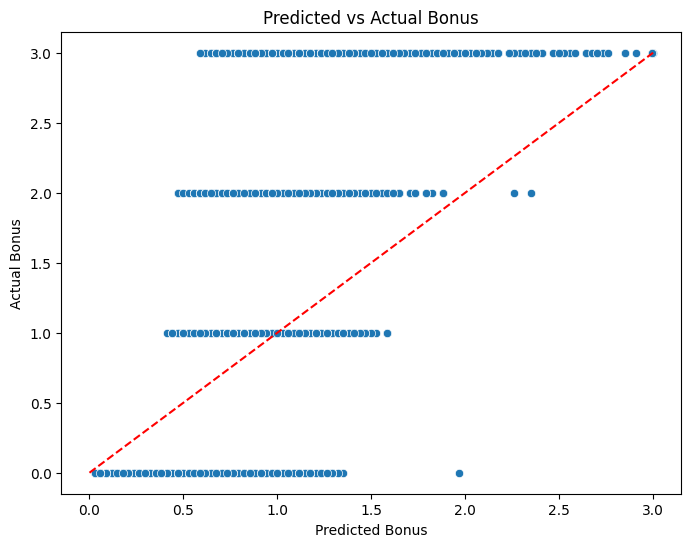

Actual Bonus       0.0       1.0       2.0       3.0
Position                                            
DEF           0.459168  0.228266  1.107658  1.945961
FWD           0.332818  0.197959  1.046991  1.713878
GK            0.488109  0.244360  1.113290  2.009464
GKP                NaN       NaN       NaN       NaN
MID           0.397430  0.244311  1.050309  1.828388


C:\Users\Chris\AppData\Local\Temp\ipykernel_10932\3541705010.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_table = dfb.groupby(['position', 'bonus']).apply(lambda x: rmse(x['bonus'], x['bonus_pred']))


In [28]:
# Generalize the relationship between bps & bonus points
import statsmodels.formula.api as smf
dfb=df.copy()
filtered = (dfb['minutes']>45) & (dfb['bonus']>=0) & (dfb['bps']>0) & (dfb['position'].isin(['GK','DEF','MID','FWD']))
# df['bonus_sq'] = df['bonus']**2

model = smf.ols('bonus ~ bps -1', data=dfb[filtered]).fit()
print(model.summary())

dfb['bonus_pred'] = model.predict(dfb[filtered])
dfb['bonus_pred'] = np.clip(dfb['bonus_pred'], 0, 3) # clip prediction to 3

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x='bonus_pred', y='bonus', data=dfb)
plt.plot([dfb['bonus'].min(), dfb['bonus'].max()],
         [dfb['bonus'].min(), dfb['bonus'].max()],
         color='red', linestyle='--')  # 45-degree line
plt.xlabel('Predicted Bonus')
plt.ylabel('Actual Bonus')
plt.title('Predicted vs Actual Bonus')
plt.show()

import pandas as pd
import numpy as np

# Function to calculate RMSE
def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

# Group by position and actual bonus, then calculate RMSE
rmse_table = dfb.groupby(['position', 'bonus']).apply(lambda x: rmse(x['bonus'], x['bonus_pred']))

# Convert to DataFrame
rmse_table = rmse_table.reset_index()
rmse_table.columns = ['Position', 'Actual Bonus', 'RMSE']

pivot_rmse = rmse_table.pivot(index='Position', columns='Actual Bonus', values='RMSE')
print(pivot_rmse)


In [29]:
#Add bonus prediction to data
prediction_data['bonus_pred'] = model.predict(prediction_data)
print("bonus_pred added to prediction data")

bonus_pred added to prediction data


C:\Users\Chris\AppData\Local\Temp\ipykernel_10932\2545047019.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['bonus_pred'] = model.predict(prediction_data)


In [30]:
target_col_name = 'xsavesp90_pred'
saves_model_dict = {'GK':GK_saves_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, saves_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_10932\803536942.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, saves_model_dict, col_name=target_col_name)


count    118.000000
mean       3.128996
std        0.647124
min        1.233645
25%        2.754408
50%        3.112649
75%        3.480764
max        5.383817
Name: xsavesp90_pred, dtype: float64

In [31]:
target_col_name = 'xdefconp90_pred'
defcon_model_dict = {'FWD': FWD_defcon_predictor, 'MID': MID_defcon_predictor, 'DEF': DEF_defcon_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, defcon_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_10932\2777375241.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, defcon_model_dict, col_name=target_col_name)


count    1525.000000
mean        7.879394
std         1.892666
min         2.126603
25%         6.641862
50%         8.032275
75%         9.284103
max        14.373934
Name: xdefconp90_pred, dtype: float64

In [32]:
prediction_data[prediction_data['position']=='MID'].head()[["player_name_id","element","value","team_name","position","season","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xgcp90_pred'
    ]]

,player_name_id,element,value,team_name,position,season,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xgcp90_pred
135677,Adam Wharton,273.0,50.0,Crystal Palace,MID,20252026.0,36.0,Man City,1245.893264,63.350985,0.060773,0.099753,1.742744
135679,Adam Wharton,273.0,50.0,Crystal Palace,MID,20252026.0,36.0,Everton,1055.499286,65.297915,0.076063,0.109722,1.415126
135681,Adam Wharton,273.0,50.0,Crystal Palace,MID,20252026.0,37.0,Brentford,1072.120197,65.297915,0.076063,0.109722,1.386370
135683,Adam Wharton,273.0,50.0,Crystal Palace,MID,20252026.0,38.0,Arsenal,1244.117493,66.072852,0.064859,0.103941,1.743055
135712,Adama Traoré Diarra,326.0,51.0,West Ham,MID,20252026.0,36.0,Arsenal,1244.117493,26.305388,0.071174,0.036419,1.623635


In [33]:
prediction_data[
    (prediction_data['event']==current_gw+1)
    &(prediction_data['mins_pred']>0)
    ][["player_name_id","element","value","team_name","position","season","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xgcp90_pred'
    ]].sort_values(by='xgp90_pred',ascending=False
        ).head(10)

,player_name_id,element,value,team_name,position,season,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xgcp90_pred
140813,Erling Haaland,430.0,146.0,Man City,FWD,20252026.0,36.0,Brentford,1072.120197,63.466297,0.771218,0.094179,1.026024
140812,Erling Haaland,430.0,146.0,Man City,FWD,20252026.0,36.0,Crystal Palace,1041.041736,77.423131,0.565540,0.046912,1.017026
149512,Mohammed Kudus,582.0,64.0,Spurs,MID,20252026.0,36.0,Leeds,1014.854573,41.950460,0.545840,0.268203,1.355467
145661,João Pedro Junqueira de Jesus,249.0,75.0,Chelsea,FWD,20252026.0,36.0,Liverpool,1161.616507,66.358658,0.544367,0.118617,1.671354
138547,Eddie Nketiah,284.0,54.0,Crystal Palace,FWD,20252026.0,36.0,Everton,1055.499286,43.733294,0.543802,0.219916,1.484009
139640,Danny Welbeck,178.0,63.0,Brighton,FWD,20252026.0,36.0,Wolves,922.621753,62.152471,0.538173,0.094803,1.380170
141121,Facundo Buonanotte,168.0,46.0,Leeds,MID,20252026.0,36.0,Spurs,978.335753,38.629127,0.531070,0.112682,1.169281
138545,Eddie Nketiah,284.0,54.0,Crystal Palace,FWD,20252026.0,36.0,Man City,1245.893264,44.386398,0.528541,0.219177,2.291345
153311,Stefanos Tzimas,180.0,52.0,Brighton,FWD,20252026.0,36.0,Wolves,922.621753,42.763760,0.525849,0.208677,1.074462
148059,Mikel Merino Zazón,22.0,54.0,Arsenal,MID,20252026.0,36.0,West Ham,1001.489826,43.802373,0.524509,0.131363,1.213217


In [34]:
# -----------------------------------------------------------------------
# Build per-player overperformance factors from ALL historical data in df
# -----------------------------------------------------------------------
# stat_pairs: (actual_column, expected_column, output_key)
#   'xg' key  → will be applied to xgp90_pred
#   'xa' key  → will be applied to xap90_pred

from FPLStatOverperformanceAnalyzer import (
    FPLStatOverperformanceAnalyzer,
    build_player_adjustments,
    apply_adjustments,
)

overperf_adjustments = build_player_adjustments(
    df,
    stat_pairs=[
        ('goals_scored',  'expected_goals',   'xg'),
        ('assists',       'expected_assists',  'xa')],
    taper_k_90s=15.0, # 15 90s needed for 50% credibility (50% observed & 50% prior(1))
    only_if_significant=True, # only adjust if p < 0.05
    min_xstat=2.0, # need ≥2 cumulative xG/xA to run test
)

print(f"Computed adjustments for {len(overperf_adjustments)} players")

# Apply factors to prediction_data
#   - Saves original columns as xgp90_pred_raw / xap90_pred_raw
#   - Adds xg_overperf_factor / xa_overperf_factor columns for audit
prediction_data = apply_adjustments(
    prediction_data,
    overperf_adjustments,
    col_map={
        'xg': 'xgp90_pred',
        'xa': 'xap90_pred',
    },
)

# Show the adjustment for the next gameweek's top players
print(f"\nNext GW{current_gw + 1} Top Players with Overperformance Factors:")
(
    prediction_data[prediction_data['event'] == current_gw + 1]
    [['player_name_id','position', 'xg_overperf_factor', 'xa_overperf_factor',
      'xgp90_pred_raw', 'xgp90_pred',
      'xap90_pred_raw', 'xap90_pred']].groupby('player_name_id').agg({'position': 'first', 'xg_overperf_factor': 'mean', 'xa_overperf_factor': 'mean',
                                                                      'xgp90_pred_raw': 'mean', 'xgp90_pred': 'mean', 'xap90_pred_raw': 'mean', 'xap90_pred': 'mean'})
    .sort_values('xg_overperf_factor', ascending=False)
    .head(30))

Computed adjustments for 2614 players

Next GW36 Top Players with Overperformance Factors:


c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\FPLStatOverperformanceAnalyzer.py:109: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[f"{col}_raw"]             = prediction_data[col].copy()
c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\FPLStatOverperformanceAnalyzer.py:110: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[col]                      = prediction_data[col] * factors
c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\FPLStatOv

,position,xg_overperf_factor,xa_overperf_factor,xgp90_pred_raw,xgp90_pred,xap90_pred_raw,xap90_pred
player_name_id,,,,,,,
Bernardo Mota Veiga de Carvalho e Silva,MID,4.686507,4.522283,0.147584,0.691654,0.189555,0.857219
Reece James,DEF,4.134913,2.956513,0.177841,0.735356,0.300491,0.888406
Mason Mount,MID,3.907183,5.260819,0.170034,0.664353,0.104500,0.549757
John Stones,DEF,3.577495,1.000000,0.170766,0.610914,0.037584,0.037584
Michael Keane,DEF,2.913623,1.000000,0.066049,0.192441,0.038846,0.038846
Youri Tielemans,MID,2.719398,2.297307,0.143261,0.389583,0.163689,0.376044
Conor Gallagher,MID,2.627693,3.285641,0.103365,0.271612,0.084188,0.276613
James Ward-Prowse,MID,2.520315,1.772663,0.129617,0.326677,0.112967,0.200252
Phil Foden,MID,2.508490,1.742554,0.331143,0.830669,0.128424,0.223786


In [35]:
import pandas as pd
from scipy.stats import nbinom

def calculate_negbinom_parameters(position_list, df):

    # 1. Calculate mean and variance
    filtered = (df['minutes'] > 0) & (df['defensive_contribution_per90'] > 0) & (df['defensive_contribution_per90'] < 40) & (df['position'].isin(position_list))
    mean = df[filtered]['defensive_contribution_per90'].mean()
    variance = df[filtered]['defensive_contribution_per90'].var()
    # r = number of successes
    r = (mean**2) / (variance - mean)
    # p = success probability
    p = r / (r + mean)
    return r,p

In [36]:
from scipy.stats import poisson
import numpy as np

def expected_score(mu, max_events=10, rule=None, points_per_n=None, points_value=None):
    """
    Calculate the expected score given an average event rate (mu)
    using a Poisson model.

    Parameters
    ----------
    mu : float
        Expected number of events (e.g., goals conceded, shots saved).
    max_events : int
        Maximum number of discrete events to sum over.
    rule : callable, optional
        Function that maps event count -> points. Example: lambda k: -np.floor(k / 2)
    points_per_n : int, optional
        For simple rules: number of events required for one point (e.g. 3 shots saved = 1 pt)
    points_value : float, optional
        Value of that one point (e.g. +1 for shots saved, -1 for goals conceded)

    Returns
    -------
    float
        Expected points based on Poisson-distributed event counts.
    """
    array = np.arange(0, max_events + 1)
    probs = poisson.pmf(array, mu)

    if rule is not None:
        scores = np.array([rule(k) for k in array])
    elif points_per_n is not None and points_value is not None:
        # General simple rule: 1 point_value for every n events
        scores = np.floor(array / points_per_n) * points_value
    else:
        raise ValueError("You must provide either a rule function or both points_per_n and points_value.")

    return np.sum(scores * probs)


In [37]:
from scipy.stats import norm
import numpy as np

scoring_dict = {
    "FWD": {'xgp90_pred': 4, 'xap90_pred': 3, 'xgcp90_pred': 0, 'xgc_ss':0, 'defcon':2},
    "MID": {'xgp90_pred': 5, 'xap90_pred': 3, 'xgcp90_pred': 1, 'xgc_ss':0, 'defcon':2},
    "DEF": {'xgp90_pred': 6, 'xap90_pred': 3, 'xgcp90_pred': 4, 'xgc_ss':-1, 'defcon':2},
    "GK":  {'xgp90_pred': 10, 'xap90_pred': 3, 'xgcp90_pred': 4, 'xgc_ss':-1, 'defcon':2}
}

def scoring(x, scoring_dict, points_type, negbinom_rp_dict=None):
    mins_factor = x['mins_pred']/90
    if points_type == 'mins':
        if pd.isna(x['mins_pred']):
            return 0
        elif x['mins_pred'] > 0:
            return 1 + 1 / (1 + np.exp(-(x['mins_pred'] - 60) / 10)) #smooth logistic approximation from 1 to 2 points, 10 is a scale factor
        
    if points_type == 'goals':
        goals_points = mins_factor * x['xgp90_pred'] * scoring_dict[x['position']]['xgp90_pred']
        return goals_points
    if points_type == 'assists':
        assist_points = mins_factor * x['xap90_pred'] * scoring_dict[x['position']]['xap90_pred']
        return assist_points
    if points_type == 'clean_sheets':
        p_less_than_1 = poisson.cdf(0, mu=x['xgcp90_pred'])
        cs_points = p_less_than_1 * scoring_dict[x['position']]['xgcp90_pred']
        return cs_points
    
    if points_type == 'shots_saved': 
        if x['position'] == 'GK':
            saves_points = expected_score(mu=x['xsavesp90_pred'],  # expected shots saved per 90
                                   max_events=15,
                                   points_per_n=3, #for every 3 shots saved
                                   points_value=1) #scores 1 point
            return saves_points
        else:
            return 0
        
    if points_type == 'goals_conceded':
        if x['position'] in ['DEF','GK']:
            gc_points = expected_score(mu=x['xgcp90_pred'], 
                                   max_events=10, 
                                   points_per_n=2, #for every 2 goals conceded 
                                   points_value=-1) #scores -1 points 
            return gc_points
        else:
            return 0

    if points_type == 'defcon':
        pos = x['position']
        if pos in ['MID','FWD']:
            r = negbinom_rp_dict[pos]['r']
            p = negbinom_rp_dict[pos]['p']
            k = 12
            prob_more_than_12 = 1 - nbinom.cdf(k, r, p)
            defcon_points = prob_more_than_12 * scoring_dict[pos]['defcon']
            return defcon_points
        elif pos == 'DEF':
            r = negbinom_rp_dict[pos]['r']
            p = negbinom_rp_dict[pos]['p']
            k = 10
            prob_more_than_12 = 1 - nbinom.cdf(k, r, p)
            defcon_points = prob_more_than_12 * scoring_dict[pos]['defcon']
            return defcon_points
        else: return 0

    if points_type == 'bonus':
        return x['xbpsp90_pred']*0.0294 # ols regression coefficient

prediction_data['xpoints_mins'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='mins'), axis=1)
prediction_data['xpoints_goals'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals'), axis=1)
prediction_data['xpoints_assists'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='assists'), axis=1)
prediction_data['xpoints_clean_sheets'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='clean_sheets'), axis=1)

prediction_data['xpoints_shots_saved'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='shots_saved'), axis=1)
prediction_data['xpoints_goals_conceded'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals_conceded'), axis=1)

def_r,def_p = calculate_negbinom_parameters(['DEF'], df)
mid_r,mid_p = calculate_negbinom_parameters(['MID'], df)
fwd_r,fwd_p = calculate_negbinom_parameters(['FWD'], df)
rp_dict = {'DEF':{'r':def_r,'p':def_p},'MID':{'r':mid_r,'p':mid_p},'FWD':{'r':fwd_r,'p':fwd_p}}
prediction_data['xpoints_defcon'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='defcon', negbinom_rp_dict=rp_dict), axis=1)
prediction_data['xpoints_bonus'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='bonus'), axis=1)

prediction_data['xpoints'] = prediction_data[['xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets',
                                              'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus']].sum(axis=1, skipna=True)

C:\Users\Chris\AppData\Local\Temp\ipykernel_10932\3158721815.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['xpoints_mins'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='mins'), axis=1)
C:\Users\Chris\AppData\Local\Temp\ipykernel_10932\3158721815.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['xpoints_goals'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals'), axis=1)
C:\Users\Chris\AppData\Local\Temp\ipykerne

In [38]:
predictions = prediction_data[['player_name_id', 'team_name','team_elo','element','position','opp_team_name','opp_team_elo', 'season', 'value', 'event','fixture',
                       'mins_pred', 'xgp90_pred', 'xap90_pred', 'xgcp90_pred',
                       'xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xg_overperf_factor', 'xa_overperf_factor','xpoints_clean_sheets','xpoints_shots_saved',
                       'xpoints_goals_conceded','xpoints_defcon','xpoints_bonus','xpoints']]
fixture_predictions = predictions.copy()  # keep per-fixture detail
# Existing per-fixture xpoints are computed above
# Now aggregate to gameweek level by summing across fixtures within each event

predictions_by_gw = predictions.groupby(
    ['player_name_id', 'element', 'team_name', 'position', 'season', 'event', 'value'],
    as_index=False,
    dropna=False
).agg(
    # descriptive
    team_name=('team_name', 'first'),
    team_elo=('team_elo', 'first'),
    opp_team_name=('opp_team_name', lambda x: '; '.join(x.dropna())), # concatenate opponent names for multiple fixtures
    opp_team_elo=('opp_team_elo', 'mean'),
    position=('position', 'first'),
    value=('value', 'first'),
    #count fixtures to identify DGWs
    fixture_count=('fixture', 'count'),
    #sum points components across fixtures
    mins_pred=('mins_pred', 'sum'),
    xpoints=('xpoints', 'sum'),
    xpoints_mins=('xpoints_mins', 'sum'),
    xpoints_goals=('xpoints_goals', 'sum'),
    xpoints_assists=('xpoints_assists', 'sum'),
    xg_overperf_factor=('xg_overperf_factor', 'mean'),
    xa_overperf_factor=('xa_overperf_factor', 'mean'),
    xpoints_clean_sheets=('xpoints_clean_sheets', 'sum'),
    xpoints_shots_saved=('xpoints_shots_saved', 'sum'),
    xpoints_goals_conceded=('xpoints_goals_conceded', 'sum'),
    xpoints_defcon=('xpoints_defcon', 'sum'),
    xpoints_bonus=('xpoints_bonus', 'sum'),
    # rates average across fixtures
    xgp90_pred=('xgp90_pred', 'mean'),
    xap90_pred=('xap90_pred', 'mean'),
    xgcp90_pred=('xgcp90_pred', 'mean'),
)

predictions_by_gw[predictions_by_gw['player_name_id'].isna()]

,player_name_id,element,season,event,team_name,team_elo,opp_team_name,opp_team_elo,position,value,...,xg_overperf_factor,xa_overperf_factor,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xgp90_pred,xap90_pred,xgcp90_pred


In [39]:
#use for fixture-level analysis
table_name = "predictions_by_fixture"
if __name__ == "__main__":
    db_creator.create_staging_table_then_insert_data(table_name, data=fixture_predictions)
    # preds = db_creator.table_to_df(table_name=table_name)
    # print(preds.info())

In [40]:
#use to make transfer decisions at gameweek level
table_name = "predictions"
if __name__ == "__main__":
    db_creator.create_staging_table_then_insert_data(table_name, data=predictions_by_gw)
    preds = db_creator.table_to_df(table_name=table_name)
    print(preds.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1590 entries, 0 to 1589
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   player_name_id          1590 non-null   object 
 1   element                 1590 non-null   float64
 2   season                  1590 non-null   float64
 3   event                   1590 non-null   float64
 4   team_name               1590 non-null   object 
 5   team_elo                1590 non-null   float64
 6   opp_team_name           1590 non-null   object 
 7   opp_team_elo            1590 non-null   float64
 8   position                1590 non-null   object 
 9   value                   1590 non-null   float64
 10  fixture_count           1590 non-null   float64
 11  mins_pred               1590 non-null   float64
 12  xpoints                 1590 non-null   float64
 13  xpoints_mins            1590 non-null   float64
 14  xpoints_goals           1590 non-null   

In [41]:
# Add new columns to the xPoints table
db_creator.execute_sql("""
    ALTER TABLE predictions
    ADD COLUMN IF NOT EXISTS in_any_team INTEGER DEFAULT 0,
    ADD COLUMN IF NOT EXISTS in_my_team INTEGER DEFAULT 0,
    ADD COLUMN IF NOT EXISTS latest_any_team INTEGER DEFAULT 0,
    ADD COLUMN IF NOT EXISTS latest_my_team INTEGER DEFAULT 0
""")

In [42]:
my_name = "Christopher Harris"

# Get the player lists
view = db_creator.run_sql(f"""
    WITH 
    current_players AS (
        SELECT element
        FROM fpl_picks
        WHERE gw = {current_gw}
    ),
    my_players AS (
        SELECT element
        FROM fpl_picks
        WHERE gw = {current_gw}
        AND member = '{my_name}'
    )
    SELECT * FROM my_players
""")

# Update the flags
db_creator.execute_sql(f"""
    UPDATE predictions
    SET in_any_team = 1
    WHERE element IN (
        SELECT element 
        FROM fpl_picks 
        WHERE gw = {current_gw}
    )
""")

db_creator.execute_sql(f"""
    UPDATE predictions
    SET in_my_team = 1
    WHERE element IN (
        SELECT element 
        FROM fpl_picks 
        WHERE gw = {current_gw}
        AND member = '{my_name}'
    )
""")

## Update flags to identify teams before the freehit
db_creator.execute_sql(f"""
    UPDATE predictions
    SET latest_any_team = 1
    WHERE element IN (
        SELECT p.element
        FROM fpl_picks p
        JOIN gw_summary s ON p.member = s.member AND s.event = {current_gw}
        WHERE 
            -- Scenario 1: Standard week for the member (not on Free Hit)
            (s.chip IS DISTINCT FROM 'freehit' AND p.gw = {current_gw})
            
            OR 
            
            -- Scenario 2: Member is on Free Hit (revert to previous week's squad)
            (s.chip = 'freehit' AND p.gw = {current_gw - 1})
    )
""")

## Using same logic as above, If I used freehit this gw, set latest_my_team to previous gw's team
db_creator.execute_sql(f"""
    UPDATE predictions
    SET latest_my_team = 1
    WHERE element IN (
        SELECT p.element
        FROM fpl_picks p
        JOIN gw_summary s ON p.member = s.member AND s.event = {current_gw}
        WHERE p.member = '{my_name}'
          AND (
            -- If you didn't Free Hit, take your current picks
            (s.chip IS DISTINCT FROM 'freehit' AND p.gw = {current_gw})
            
            OR 
            
            -- If you DID Free Hit, take your picks from the previous GW
            (s.chip = 'freehit' AND p.gw = {current_gw - 1})
          )
    )
""")



In [43]:
view = db_creator.run_sql(f"""SELECT event, member, chip
                          FROM gw_summary
                          WHERE chip = 'freehit'
                            AND event = {current_gw}
                            """)
view

,event,member,chip


In [44]:
view = db_creator.run_sql("""SELECT *
                          FROM fpl_picks
                          LEFT JOIN gw_summary ON fpl_picks.member = gw_summary.member
                            AND fpl_picks.gw = gw_summary.event
                          WHERE chip = 'freehit'
                            """)
view

,member,memberid,season,div,gw,pick,element,position,multiplier,is_captain,...,bank,value,event_transfers,event_transfers_cost,points_on_bench,member,memberid,chip,season,div
0,Christopher Harris,145486.0,20252026.0,1.0,15.0,15.0,116.0,15.0,0.0,False,...,70.0,1000.0,0.0,0.0,1.0,Christopher Harris,145486.0,freehit,20252026.0,1.0
1,Christopher Harris,145486.0,20252026.0,1.0,15.0,14.0,100.0,14.0,0.0,False,...,70.0,1000.0,0.0,0.0,1.0,Christopher Harris,145486.0,freehit,20252026.0,1.0
2,Christopher Harris,145486.0,20252026.0,1.0,15.0,13.0,256.0,13.0,0.0,False,...,70.0,1000.0,0.0,0.0,1.0,Christopher Harris,145486.0,freehit,20252026.0,1.0
3,Christopher Harris,145486.0,20252026.0,1.0,15.0,12.0,567.0,12.0,0.0,False,...,70.0,1000.0,0.0,0.0,1.0,Christopher Harris,145486.0,freehit,20252026.0,1.0
4,Christopher Harris,145486.0,20252026.0,1.0,15.0,11.0,430.0,11.0,2.0,True,...,70.0,1000.0,0.0,0.0,1.0,Christopher Harris,145486.0,freehit,20252026.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,Callum Harling,2506220.0,20252026.0,1.0,14.0,5.0,497.0,5.0,1.0,False,...,41.0,988.0,0.0,0.0,1.0,Callum Harling,2506220.0,freehit,20252026.0,1.0
191,Callum Harling,2506220.0,20252026.0,1.0,14.0,4.0,256.0,4.0,1.0,False,...,41.0,988.0,0.0,0.0,1.0,Callum Harling,2506220.0,freehit,20252026.0,1.0
192,Callum Harling,2506220.0,20252026.0,1.0,14.0,3.0,7.0,3.0,1.0,False,...,41.0,988.0,0.0,0.0,1.0,Callum Harling,2506220.0,freehit,20252026.0,1.0
193,Callum Harling,2506220.0,20252026.0,1.0,14.0,2.0,8.0,2.0,1.0,False,...,41.0,988.0,0.0,0.0,1.0,Callum Harling,2506220.0,freehit,20252026.0,1.0


In [45]:
view = db_creator.run_sql("""SELECT
                        player_name_id, team_name, team_elo, season, event, fixture_count, opp_team_name, opp_team_elo, xpoints, fixture_count
                            FROM predictions
                        WHERE season = 20252026 
                          AND event = 33
                          AND player_name_id = 'Cole Palmer'
                            """)
view

,player_name_id,team_name,team_elo,season,event,fixture_count,opp_team_name,opp_team_elo,xpoints,fixture_count


In [46]:
print(f"Gameweek {current_gw+1} Predictions")
predictions_by_gw[
    predictions_by_gw['event']==current_gw+1
].pivot_table(index=['player_name_id',"element",'event',"value","team_name","position"], values='xpoints', aggfunc='sum').reset_index().sort_values(by='xpoints', ascending=False).head(20)

Gameweek 36 Predictions


,player_name_id,element,event,value,team_name,position,xpoints
55,Bernardo Mota Veiga de Carvalho e Silva,416.0,36.0,62.0,Man City,MID,15.336449
247,John Stones,409.0,36.0,54.0,Man City,DEF,10.885503
140,Erling Haaland,430.0,36.0,146.0,Man City,FWD,10.019704
342,Matheus Nunes,407.0,36.0,53.0,Man City,DEF,9.831155
32,Antoine Semenyo,82.0,36.0,82.0,Man City,MID,9.690321
329,Marc Guéhi,260.0,36.0,51.0,Man City,DEF,9.569261
388,Nico O'Reilly,411.0,36.0,52.0,Man City,DEF,9.372809
269,Joško Gvardiol,403.0,36.0,58.0,Man City,DEF,9.338159
452,Rúben dos Santos Gato Alves Dias,408.0,36.0,55.0,Man City,DEF,8.726113
426,Rayan Cherki,417.0,36.0,65.0,Man City,MID,8.547433


In [47]:
print(f"Next 5 GWs: GW{current_gw+1} - GW{current_gw+5}")
next_5_gws_filter = (predictions_by_gw['event']>=current_gw)&(predictions_by_gw['event']<=current_gw+5)
predictions_by_gw[next_5_gws_filter].groupby('player_name_id')[['mins_pred', 'xpoints_mins', 'xpoints_goals', 
                                           'xpoints_assists', 'xpoints_clean_sheets', 'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                                           'xpoints'
                                           ]].agg('sum').reset_index().sort_values(by='xpoints',ascending=False).head(10)

Next 5 GWs: GW36 - GW40


,player_name_id,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
55,Bernardo Mota Veiga de Carvalho e Silva,249.351271,6.098434,9.534462,7.210884,1.438220,0.0,0.000000,2.042784,2.084139,28.408923
429,Reece James,182.547506,4.563573,9.010963,5.715464,2.743304,0.0,-1.525058,1.606441,1.230205,23.344892
247,John Stones,215.526600,5.407838,8.743451,0.263137,4.567509,0.0,-1.592026,2.141921,2.096407,21.628238
140,Erling Haaland,267.822021,6.608381,8.363380,2.296079,0.000000,0.0,0.000000,1.065928,1.836249,20.170017
165,Gabriel dos Santos Magalhães,258.886183,5.798216,2.649047,0.672460,7.129276,0.0,-0.317579,1.606441,1.922888,19.460749
329,Marc Guéhi,281.225586,6.816720,2.485667,0.774981,5.720862,0.0,-1.187755,2.141921,2.093766,18.846162
342,Matheus Nunes,262.740223,6.381757,0.832474,2.661611,5.821183,0.0,-1.164281,2.141921,1.920894,18.595560
269,Joško Gvardiol,219.478486,5.497930,2.389691,2.683313,5.011294,0.0,-1.423094,2.141921,2.033993,18.335049
32,Antoine Semenyo,222.113739,5.579019,4.571241,2.343597,1.430352,0.0,0.000000,2.042784,2.336223,18.303216
388,Nico O'Reilly,259.678358,6.367418,1.966737,0.551646,5.942338,0.0,-1.128257,2.141921,2.074690,17.916494


In [48]:
print("Rest of Season Predictions")
predictions_by_gw.groupby('player_name_id')[['team_name','opp_team_elo','mins_pred',
                                           'xpoints', 'xpoints_mins', 'xpoints_goals', 
                                           'xpoints_assists', 'xpoints_clean_sheets', 
                                           'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus'
                                           ]].agg({'team_name':'first','opp_team_elo':'mean','mins_pred':'mean','xpoints':'sum', 'xpoints_mins':'sum', 'xpoints_goals':'sum',
                                           'xpoints_assists':'sum', 'xpoints_clean_sheets':'sum',
                                           'xpoints_shots_saved':'sum','xpoints_goals_conceded':'sum','xpoints_defcon':'sum','xpoints_bonus':'sum'}
                                                  ).reset_index().sort_values(by='xpoints',ascending=False).head(10)

Rest of Season Predictions


,player_name_id,team_name,opp_team_elo,mins_pred,xpoints,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus
55,Bernardo Mota Veiga de Carvalho e Silva,Man City,1088.483016,83.117090,28.408923,6.098434,9.534462,7.210884,1.438220,0.0,0.000000,2.042784,2.084139
429,Reece James,Chelsea,1055.615340,60.849169,23.344892,4.563573,9.010963,5.715464,2.743304,0.0,-1.525058,1.606441,1.230205
247,John Stones,Man City,1088.483016,71.842200,21.628238,5.407838,8.743451,0.263137,4.567509,0.0,-1.592026,2.141921,2.096407
140,Erling Haaland,Man City,1088.483016,89.274007,20.170017,6.608381,8.363380,2.296079,0.000000,0.0,0.000000,1.065928,1.836249
165,Gabriel dos Santos Magalhães,Arsenal,969.554106,86.295394,19.460749,5.798216,2.649047,0.672460,7.129276,0.0,-0.317579,1.606441,1.922888
329,Marc Guéhi,Man City,1088.483016,93.741862,18.846162,6.816720,2.485667,0.774981,5.720862,0.0,-1.187755,2.141921,2.093766
342,Matheus Nunes,Man City,1088.483016,87.580074,18.595560,6.381757,0.832474,2.661611,5.821183,0.0,-1.164281,2.141921,1.920894
269,Joško Gvardiol,Man City,1088.483016,73.159495,18.335049,5.497930,2.389691,2.683313,5.011294,0.0,-1.423094,2.141921,2.033993
32,Antoine Semenyo,Man City,1088.483016,74.037913,18.303216,5.579019,4.571241,2.343597,1.430352,0.0,0.000000,2.042784,2.336223
388,Nico O'Reilly,Man City,1088.483016,86.559453,17.916494,6.367418,1.966737,0.551646,5.942338,0.0,-1.128257,2.141921,2.074690


In [49]:
from datetime import datetime

# Add the columns
db_creator.execute_sql("""
    ALTER TABLE predictions
    ADD COLUMN IF NOT EXISTS prediction_timestamp TIMESTAMP,
    ADD COLUMN IF NOT EXISTS prediction_gameweek INTEGER;
""")

# Update ALL existing rows with current timestamp and gameweek
db_creator.execute_sql("""
    UPDATE predictions
    SET prediction_timestamp = :timestamp,
        prediction_gameweek = :gameweek;
""", params={
    'timestamp': datetime.now(),
    'gameweek': current_gw
})

In [50]:
# ## Reset predictions table

# db_creator.execute_sql("""
#     DROP TABLE IF EXISTS predictions_allgws
# """)

In [51]:
# Create predictions_allgws if it doesn't exist
db_creator.execute_sql("""
    CREATE TABLE IF NOT EXISTS predictions_allgws AS
    SELECT p.*,
            -- pg.player_name_id, pg.team_name, pg.team_elo, pg.element, pg.position, pg.opp_team_name, pg.opp_team_elo, pg.value -- these are in both tables
            SUM(pg.total_points) AS total_points
            
    FROM predictions p
    LEFT JOIN playergw pg 
        ON p.player_name_id = pg.player_name_id 
        AND p.event = pg.event
        AND p.season = pg.season
    GROUP BY p.player_name_id, p.element, p.season, p.event,
             p.team_name, p.team_elo, p.position, p.value, p.in_any_team, p.in_my_team,p.latest_any_team, p.latest_my_team,
             p.opp_team_name, p.opp_team_elo, p.fixture_count,
             p.xpoints, p.xpoints_mins, p.xpoints_goals, p.xpoints_assists, p.xg_overperf_factor,p.xa_overperf_factor,
             p.xpoints_clean_sheets, p.xpoints_shots_saved, p.xpoints_goals_conceded,
             p.xpoints_defcon, p.xpoints_bonus,
             p.mins_pred, p.xgp90_pred, p.xap90_pred, p.xgcp90_pred,
             p.prediction_timestamp, p.prediction_gameweek
    Limit 0 -- no data yet, just create the table structure;
""")

In [52]:
# Step 1: Insert new predictions with current timestamp
# This will create NEW rows even for gameweeks that already have predictions
db_creator.execute_sql("""
INSERT INTO predictions_allgws (
    player_name_id, team_name, team_elo, element, position, opp_team_name, opp_team_elo, value, 
    event, season, xpoints, 
    prediction_timestamp, prediction_gameweek,
    fixture, total_points
)
SELECT 
    p.player_name_id, p.team_name, p.team_elo, p.element, p.position, p.opp_team_name, 
    p.opp_team_elo, p.value, p.event, p.season, p.xpoints, 
    p.prediction_timestamp, p.prediction_gameweek,
    pg.fixture, pg.total_points
FROM predictions p
LEFT JOIN playergw pg 
    ON p.player_name_id = pg.player_name_id 
    AND p.event = pg.event 
    AND p.season = pg.season;
""")

print(f"Successfully added {db_creator.run_sql('SELECT COUNT(*) FROM predictions').iloc[0,0]} new predictions to predictions_allgws")

Successfully added 1590 new predictions to predictions_allgws


In [53]:
view = db_creator.table_to_df('predictions_allgws')
future_filter = (
    view['prediction_gameweek']==current_gw) & (
    view['event']==current_gw+1) & (
    view['player_name_id']=='Erling Haaland')
view[['player_name_id','season','event','fixture','total_points']][future_filter].head()

,player_name_id,season,event,fixture,total_points
163794,Erling Haaland,20252026.0,36.0,307.0,NaN
163795,Erling Haaland,20252026.0,36.0,356.0,NaN


In [54]:
view = db_creator.table_to_df('playergw')
future_filter = (view['season']==20252026)&(view['event']>=25)&(view['player_name_id']=='Erling Haaland')
view[['player_name_id','event','season','total_points','minutes']][future_filter].sort_values(by='event').head(10)

,player_name_id,event,season,total_points,minutes
192964,Erling Haaland,25.0,20252026.0,11.0,90.0
192965,Erling Haaland,26.0,20252026.0,5.0,45.0
192966,Erling Haaland,27.0,20252026.0,6.0,90.0
192967,Erling Haaland,28.0,20252026.0,0.0,0.0
192968,Erling Haaland,29.0,20252026.0,2.0,90.0
192969,Erling Haaland,30.0,20252026.0,2.0,90.0
192970,Erling Haaland,32.0,20252026.0,2.0,90.0
192971,Erling Haaland,33.0,20252026.0,6.0,90.0
192972,Erling Haaland,33.0,20252026.0,7.0,90.0
192973,Erling Haaland,35.0,20252026.0,0.0,0.0


In [55]:
view = db_creator.table_to_df('predictions_allgws')
view[['player_name_id','prediction_timestamp','event','xpoints','total_points']][
    (view['season']==20252026)&(
    view['event']>=20)&(view['player_name_id']=='Erling Haaland')].sort_values(by='event')

,player_name_id,prediction_timestamp,event,xpoints,total_points
1615,Erling Haaland,2026-01-05 18:33:33.065519,21.0,5.628327,6.0
13463,Erling Haaland,2026-01-05 18:33:33.065519,22.0,5.571476,2.0
13479,Erling Haaland,2026-01-05 18:33:33.065519,23.0,7.368988,1.0
19365,Erling Haaland,2026-01-27 11:00:04.422834,24.0,3.886675,NaN
13464,Erling Haaland,2026-01-05 18:33:33.065519,24.0,5.915376,NaN
...,...,...,...,...,...
153188,Erling Haaland,2026-04-21 15:40:20.013450,38.0,4.933701,NaN
19374,Erling Haaland,2026-01-27 11:00:04.422834,38.0,3.494566,NaN
156176,Erling Haaland,2026-04-22 10:34:37.970349,38.0,5.017204,NaN
13478,Erling Haaland,2026-01-05 18:33:33.065519,38.0,4.510429,NaN


In [56]:
# Get the data from the predictions table
df_preds = db_creator.table_to_df('predictions_allgws')

# Remove rows where actual_points is missing
gw_filter=(df_preds['prediction_gameweek']>=13)&(
            df_preds['event']>=current_gw)&(
                df_preds['event']<=current_gw+5)&(
            df_preds['season']==20252026)#&(
            #df_preds['player_name_id']=='Erling Haaland')
df_complete = df_preds[gw_filter]

df_complete.pivot_table(index=['prediction_timestamp','prediction_gameweek','season','event'], values=['xpoints','total_points'])

xpoints
prediction_timestamp       prediction_gameweek season     event          
2026-01-05 18:33:33.065519 20                  20252026.0 35.0   3.388855
                                                          36.0   3.436291
                                                          37.0   3.421387
                                                          38.0   3.397330
2026-01-07 16:29:20.849190 21                  20252026.0 35.0   3.040884
...                                                                   ...
2026-04-28 21:09:59.322467 34                  20252026.0 37.0   3.392223
                                                          38.0   3.386701
2026-05-04 18:13:03.414198 35                  20252026.0 36.0   4.050692
                                                          37.0   3.399450
                                                          38.0   3.371685

[171 rows x 1 columns]

In [57]:
#Future GWs should show more than one row here when more predictions are added...
df_complete.pivot_table(index='prediction_timestamp',values='player_name_id',aggfunc='count',dropna=False)

,player_name_id
prediction_timestamp,
2026-01-05 18:33:33.065519,1940
2026-01-07 16:29:20.849190,8
2026-01-08 16:44:49.940956,8
2026-01-22 16:59:38.976316,12
2026-01-25 11:24:25.347489,4
2026-01-26 14:27:00.627006,1980
2026-01-27 11:00:04.422834,1984
2026-02-01 11:57:12.353330,1992
2026-02-02 13:38:00.840050,2004


In [58]:
filtered = (df_complete['player_name_id'] == 'Erling Haaland')&(
    df_complete['season']==20252026) & (df_complete['event']==current_gw+1)
df_complete[filtered][['prediction_timestamp','prediction_gameweek','season','event','xpoints','total_points']].sort_values(by='prediction_timestamp')

,prediction_timestamp,prediction_gameweek,season,event,xpoints,total_points
13476,2026-01-05 18:33:33.065519,20,20252026.0,36.0,5.559963,NaN
5670,2026-01-26 14:27:00.627006,23,20252026.0,36.0,4.091641,NaN
19372,2026-01-27 11:00:04.422834,23,20252026.0,36.0,3.708660,NaN
26618,2026-02-01 11:57:12.353330,24,20252026.0,36.0,3.418325,NaN
33635,2026-02-02 13:38:00.840050,24,20252026.0,36.0,4.144226,NaN
40652,2026-02-03 14:41:19.430154,24,20252026.0,36.0,4.263983,NaN
47466,2026-02-09 12:29:03.939012,25,20252026.0,36.0,4.856580,NaN
53800,2026-02-13 13:00:38.658664,26,20252026.0,36.0,4.794017,NaN
59830,2026-02-19 17:56:20.307174,26,20252026.0,36.0,4.707560,NaN
65861,2026-02-20 10:52:25.776847,26,20252026.0,36.0,4.750619,NaN


In [59]:
filtered = df_complete['prediction_gameweek']==21
df_complete[filtered][['prediction_timestamp','player_name_id','event']].describe()

,prediction_timestamp,event
count,16,16.000000
mean,2026-01-08 04:37:05.395073024,36.500000
min,2026-01-07 16:29:20.849190,35.000000
25%,2026-01-07 16:29:20.849189888,35.750000
50%,2026-01-08 04:37:05.395073024,36.500000
75%,2026-01-08 16:44:49.940955904,37.250000
max,2026-01-08 16:44:49.940956,38.000000
std,NaN,1.154701


In [60]:
# # Create the plot
# plt.figure(figsize=(10, 8))
# sns.scatterplot(data=df_complete, x='xpoints', y='total_points', alpha=0.6)

# # Add a diagonal reference line (perfect predictions)
# max_val = max(df_complete['xpoints'].max(), df_complete['total_points'].max())
# plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction', linewidth=2)

# # Add regression line showing actual correlation
# from scipy.stats import linregress
# slope, intercept, r_value, p_value, std_err = linregress(df_complete['xpoints'], df_complete['total_points'])
# x_line = np.array([df_complete['xpoints'].min(), df_complete['xpoints'].max()])
# y_line = slope * x_line + intercept
# plt.plot(x_line, y_line, 'g-', label=f'Best fit (y={slope:.2f}x+{intercept:.2f})', linewidth=2)

# print(f"Correlation: {df_complete['xpoints'].corr(df_complete['total_points']):.3f}")
# print(f"Mean Absolute Error: {(df_complete['xpoints'] - df_complete['total_points']).abs().mean():.3f}")
# print(f"Root Mean Squared Error: {((df_complete['xpoints'] - df_complete['total_points'])**2).mean()**0.5:.3f}")

# plt.xlabel('Predicted Points (xPoints)', fontsize=12)
# plt.ylabel('Actual Points', fontsize=12)
# plt.title(f'Predicted vs Actual Points in GW{current_gw}', fontsize=14, fontweight='bold')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

In [61]:
finish=time.perf_counter()
print(f'Finished in {round(((finish-start)/60),2)} minute(s)')
#10/11/25: Finished in 33.17 minute(s)

Finished in 30.03 minute(s)


In [62]:
# Notification when file has finished running
from plyer import notification

notification.notify(
    title='Script Complete',
    message='Your file has finished running!',
    app_name='Jupyter Notebook',
    timeout=20  # notification stays for 20 seconds
)